In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import seaborn as sns

In [27]:
dataset=pd.read_csv(r"C:\Users\rohit\Downloads\Titanic-Dataset.csv")

In [28]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Missing Data Imputation

In [29]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [30]:
numeric_imputer=SimpleImputer(missing_values=np.nan,strategy="mean",fill_value="constant")

In [31]:
age=numeric_imputer.fit_transform(dataset[["Age"]])


In [32]:
age=age.flatten()

In [33]:
cat_imputer=SimpleImputer(missing_values=np.nan,strategy="most_frequent",fill_value=0)

In [34]:
temp=cat_imputer.fit_transform(dataset[["Cabin","Embarked"]])


In [35]:
temp_dataset=pd.DataFrame(temp,columns=["Cabin","Embarked"])

In [36]:
temp_dataset.head()

,Cabin,Embarked
0,B96 B98,S
1,C85,C
2,B96 B98,S
3,C123,S
4,B96 B98,S


In [37]:

dataset_new=pd.concat([dataset[["PassengerId","Survived","Pclass","Name","Sex","SibSp","Parch","Ticket","Fare"]],temp_dataset,pd.DataFrame(age,columns=["Age"])],axis=1)

In [38]:
dataset=dataset_new[dataset.columns]

In [39]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S


In [40]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

##  Encoding Sex, Embarked columns

In [41]:
encoder=OneHotEncoder()

In [42]:
data_categorical=encoder.fit_transform(dataset[["Sex","Embarked"]]).toarray()

In [43]:
data_categorical=np.array(data_categorical,dtype="int")

In [44]:
col_names=encoder.get_feature_names_out()

In [45]:
categorical_dataset=pd.DataFrame(data_categorical,columns=col_names)

In [46]:
df_transformed=pd.concat([dataset[["PassengerId","Survived","Pclass","Name","Age","SibSp","Parch","Ticket","Fare"]],categorical_dataset],axis=1)

In [47]:
df_transformed.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,0,0,1


##  Visualizing age distribution using Seaborn

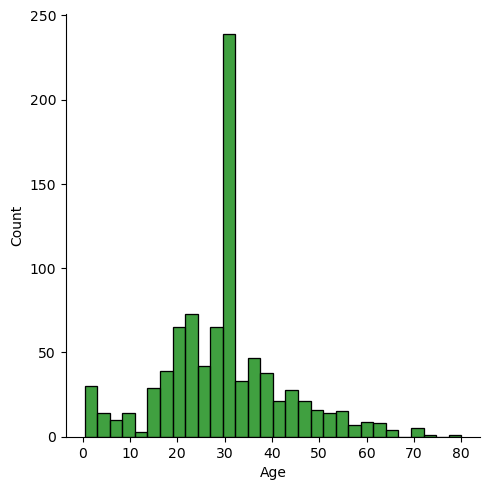

In [48]:
sns.displot(x=df_transformed["Age"],kind="hist",color="g")

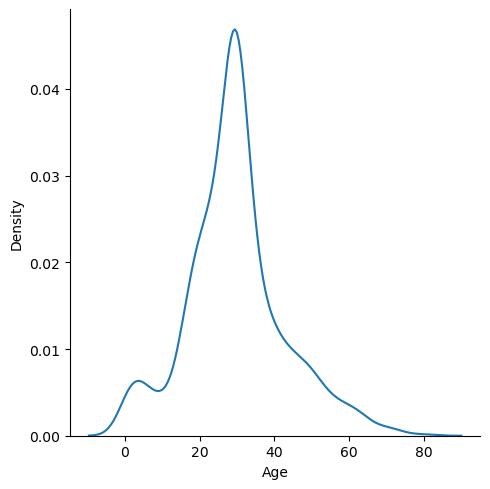

In [49]:
sns.displot(x=df_transformed["Age"],kind="kde")

## Outputting cleaned dataset as new CSV

In [50]:
df_transformed.to_csv(r"C:\Users\rohit\Downloads\Skill Nexis Internship\week-1\Mini_project_week-1\cleaned_titanic_dataset.csv")